In [1]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import load_iris
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler

# Principal Component Analysis (PCA)

## Iris dataset: scikit-learn and a from-scratch walkthrough

**Learning goals**

- Standardize features before applying PCA.
- Reduce the Iris dataset from four features to two principal components.
- Interpret explained variance and choose a useful number of components.
- Reproduce the core PCA steps with NumPy.

In [2]:
iris = load_iris()
X = iris.data
y = iris.target

print(f"Samples: {X.shape[0]}")
print(f"Original features: {X.shape[1]}")
print(f"Classes: {', '.join(iris.target_names)}")

Samples: 150
Original features: 4
Classes: setosa, versicolor, virginica


In [3]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

In [4]:
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)
variance_ratio = pca.explained_variance_ratio_

In [5]:
print(f"Original shape: {X.shape}")
print(f"Reduced shape:  {X_pca.shape}")
print(f"PC1 explains:   {variance_ratio[0]:.1%}")
print(f"PC2 explains:   {variance_ratio[1]:.1%}")
print(f"Total retained: {variance_ratio.sum():.1%}")

Original shape: (150, 4)
Reduced shape:  (150, 2)
PC1 explains:   73.0%
PC2 explains:   22.9%
Total retained: 95.8%


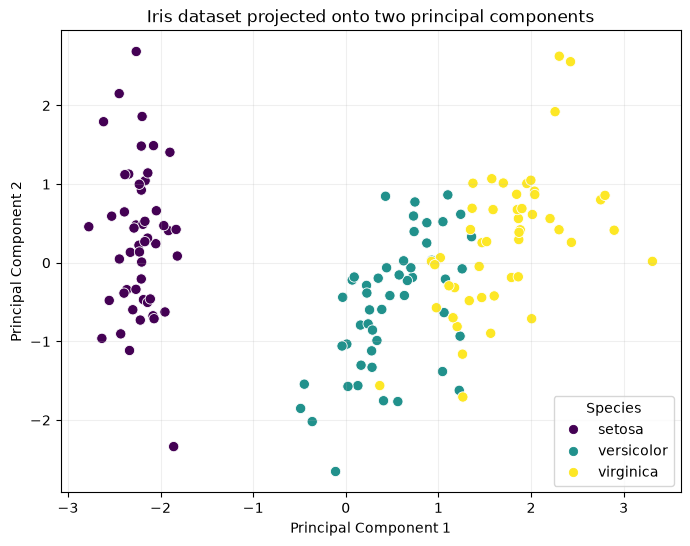

In [6]:
fig, ax = plt.subplots(figsize=(8, 6))
scatter = ax.scatter(
    X_pca[:, 0],
    X_pca[:, 1],
    c=y,
    cmap="viridis",
    s=55,
    edgecolors="white",
    linewidths=0.6,
)

ax.set(
    title="Iris dataset projected onto two principal components",
    xlabel="Principal Component 1",
    ylabel="Principal Component 2",
)
ax.legend(scatter.legend_elements()[0], iris.target_names, title="Species")
ax.grid(alpha=0.2)
plt.show()

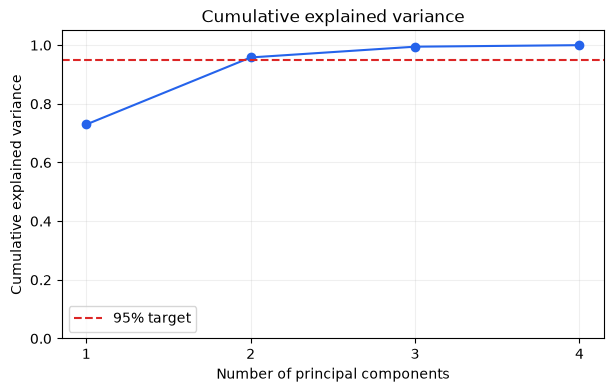

In [7]:
full_pca = PCA().fit(X_scaled)
cumulative_variance = full_pca.explained_variance_ratio_.cumsum()

fig, ax = plt.subplots(figsize=(7, 4))
components = np.arange(1, len(cumulative_variance) + 1)
ax.plot(components, cumulative_variance, marker="o", color="#2563eb")
ax.axhline(0.95, color="#dc2626", linestyle="--", label="95% target")
ax.set(
    title="Cumulative explained variance",
    xlabel="Number of principal components",
    ylabel="Cumulative explained variance",
    xticks=components,
    ylim=(0, 1.05),
)
ax.legend()
ax.grid(alpha=0.2)
plt.show()

## PCA from scratch

This compact example follows the same ideas used by scikit-learn: center the data, compute its covariance matrix, find the principal directions, and project the observations onto the most informative direction.

In [8]:
X_small = np.array([
    [2, 1],
    [3, 2],
    [4, 3],
    [5, 5],
], dtype=float)

X_small

array([[2., 1.],
       [3., 2.],
       [4., 3.],
       [5., 5.]])

In [10]:
small_mean = X_small.mean(axis=0)
X_small_centered = X_small - small_mean

print("Feature means:", small_mean)
print()
print("Centered data:")
print(X_small_centered)

Feature means: [3.5  2.75]

Centered data:
[[-1.5  -1.75]
 [-0.5  -0.75]
 [ 0.5   0.25]
 [ 1.5   2.25]]


In [11]:
covariance_matrix = np.cov(X_small_centered, rowvar=False)
print("Covariance matrix:")
print(covariance_matrix)

SyntaxError: unterminated string literal (detected at line 2) (1836153848.py, line 2)

In [ ]:
eigenvalues, eigenvectors = np.linalg.eigh(covariance_matrix)
order = eigenvalues.argsort()[::-1]
eigenvalues = eigenvalues[order]
eigenvectors = eigenvectors[:, order]

In [ ]:
print("Eigenvalues (largest first):", eigenvalues)
print()
print("Principal directions:")
print(eigenvectors)

In [ ]:
explained_variance_ratio_small = eigenvalues / eigenvalues.sum()
print("Explained variance ratio:", explained_variance_ratio_small)
print(f"PC1 retains {explained_variance_ratio_small[0]:.1%} of the variance.")

In [ ]:
pc1 = eigenvectors[:, 0]
manual_projection = X_small_centered @ pc1
print("Manual one-dimensional projection:", manual_projection)

In [ ]:
sklearn_pca = PCA(n_components=1)
sklearn_projection = sklearn_pca.fit_transform(X_small).ravel()

# PCA directions may differ only by sign, so compare absolute values.
print("scikit-learn projection:", sklearn_projection)
print("Same magnitude as manual result:", np.allclose(np.abs(manual_projection), np.abs(sklearn_projection)))